In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.chdir(r"C:\Users\bsenu\OneDrive\Masaüstü\Kişisel Projeler\cv-analiz-asistani")

# Veri setini yükle
df = pd.read_csv("data/raw/Resume.csv")

# Temel bilgiler
print("Toplam CV sayısı:", len(df))
print("Sütunlar:", df.columns.tolist())
print("Kategoriler:", df['Category'].nunique(), "adet")
print("\nEksik değerler:")
print(df.isnull().sum())
print("\nTemel istatistikler:")
print(df['Category'].value_counts())

Toplam CV sayısı: 2484
Sütunlar: ['ID', 'Resume_str', 'Resume_html', 'Category']
Kategoriler: 24 adet

Eksik değerler:
ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64

Temel istatistikler:
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
FINANCE                   118
ADVOCATE                  118
ACCOUNTANT                118
ENGINEERING               118
CHEF                      118
AVIATION                  117
FITNESS                   117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


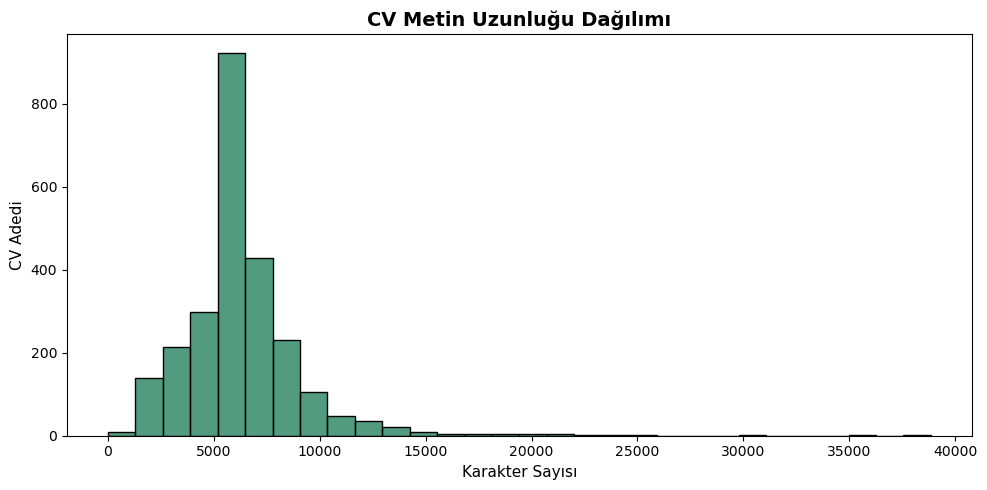

In [6]:
# Grafik 1: Metin uzunluğu dağılımı
df["metin_uzunlugu"] = df["Resume_str"].apply(len)

plt.figure(figsize=(10, 5))
sns.histplot(df["metin_uzunlugu"], bins=30, color="#187A55")
plt.title("CV Metin Uzunluğu Dağılımı", fontsize=14, fontweight="bold")
plt.xlabel("Karakter Sayısı", fontsize=11)
plt.ylabel("CV Adedi", fontsize=11)
plt.tight_layout()
plt.savefig("visuals/metin_uzunlugu.png", dpi=150)
plt.show()

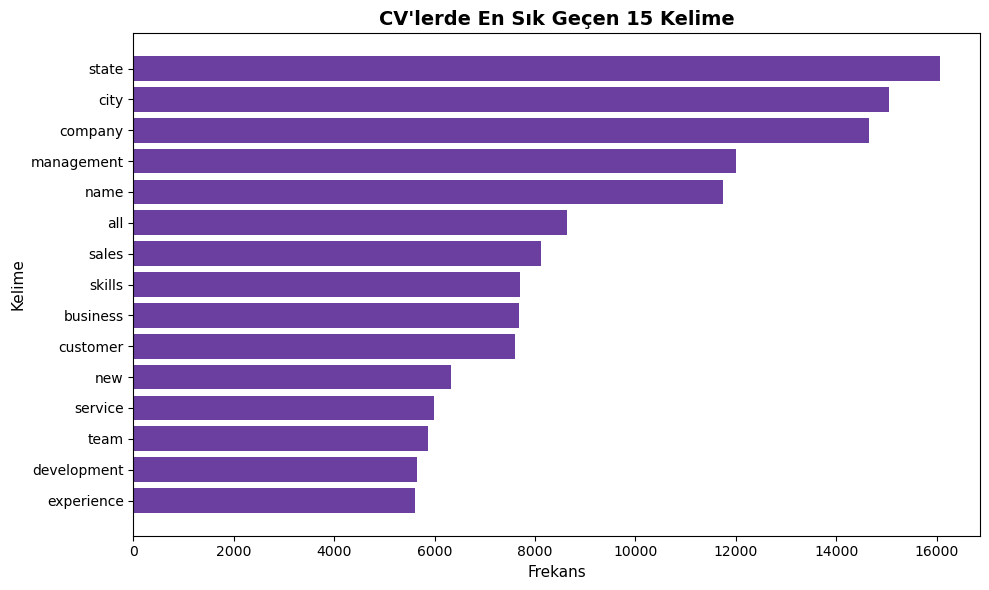

In [7]:
# Grafik 2: En sık geçen kelimeler
from collections import Counter
import re

# Tüm CV metinlerini birleştir ve temizle
tum_metin = " ".join(df["Resume_str"].tolist()).lower()
tum_metin = re.sub(r'[^a-zA-Z\s]', '', tum_metin)
kelimeler = tum_metin.split()

# Stopword listesi
stopwords = {"and","the","to","of","in","a","for","with","is","on",
             "at","as","by","an","be","or","are","from","was","have",
             "has","that","this","it","we","i","my","you","your","our"}

kelimeler_temiz = [k for k in kelimeler if k not in stopwords and len(k) > 2]
en_sik = Counter(kelimeler_temiz).most_common(15)

kelime_listesi, sayilar = zip(*en_sik)

plt.figure(figsize=(10, 6))
plt.barh(kelime_listesi, sayilar, color="#6B3FA0")
plt.title("CV'lerde En Sık Geçen 15 Kelime", fontsize=14, fontweight="bold")
plt.xlabel("Frekans", fontsize=11)
plt.ylabel("Kelime", fontsize=11)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("visuals/kelime_frekansi.png", dpi=150)
plt.show()

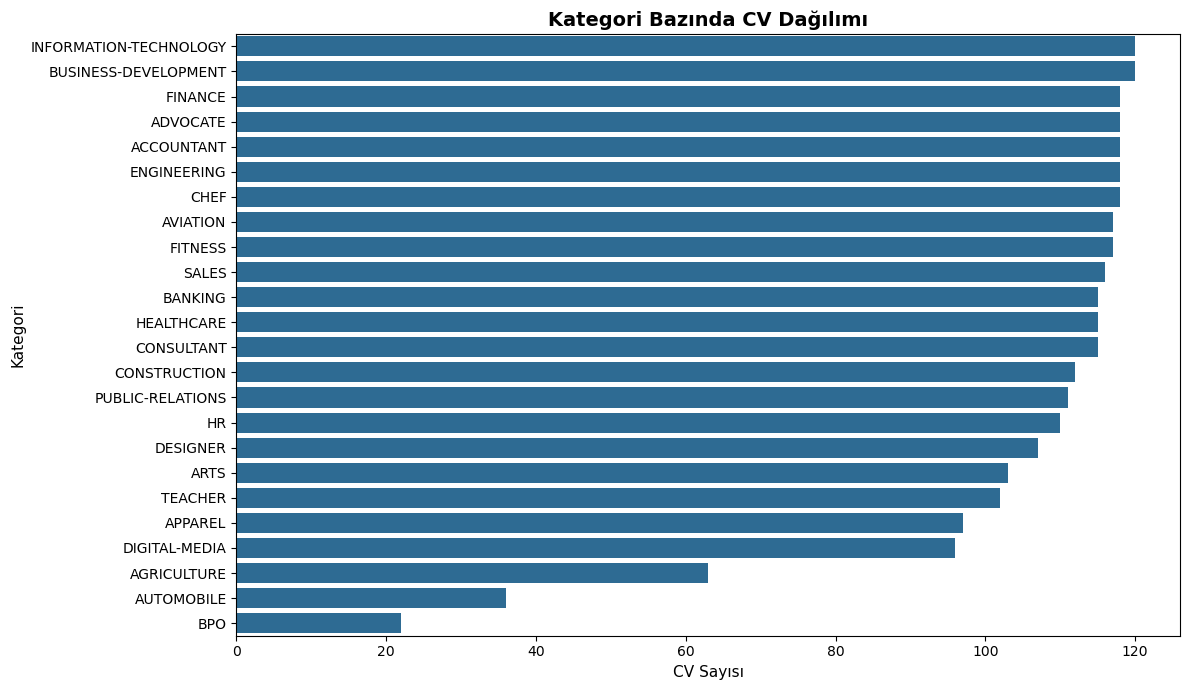

In [8]:
# Grafik 3: Kategori dağılımı
plt.figure(figsize=(12, 7))
sns.countplot(data=df, y="Category",
              order=df["Category"].value_counts().index,
              color="#1D6FA4")
plt.title("Kategori Bazında CV Dağılımı", fontsize=14, fontweight="bold")
plt.xlabel("CV Sayısı", fontsize=11)
plt.ylabel("Kategori", fontsize=11)
plt.tight_layout()
plt.savefig("visuals/kategori_dagilimi.png", dpi=150)
plt.show()

In [9]:
# Veri ön işleme
import re

def on_isle(metin):
    metin = metin.lower()                        # küçük harfe çevir
    metin = re.sub(r'[^a-zA-Z\s]', '', metin)   # özel karakter temizle
    metin = re.sub(r'\s+', ' ', metin).strip()  # fazla boşluk temizle
    return metin

df["temiz_metin"] = df["Resume_str"].apply(on_isle)

# Temizlenmiş veriyi kaydet
df[["ID", "Category", "temiz_metin"]].to_csv(
    "data/processed/Resume_temiz.csv", index=False
)

print("Ön işleme tamamlandı!")
print("Orijinal metin örneği:", df["Resume_str"][0][:100])
print("Temiz metin örneği:   ", df["temiz_metin"][0][:100])

Ön işleme tamamlandı!
Orijinal metin örneği:          HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer
Temiz metin örneği:    hr administratormarketing associate hr administrator summary dedicated customer service manager with
